In [1]:
import numpy as np
from itertools import chain
import pandas as pd
import json
from utils2 import psd
import pathlib
import matplotlib.pyplot as plt

ages_table_path = 'ages_table.xlsx'
ages_table = pd.read_excel(ages_table_path)

def get_age_years(subj, ages_table, year_to_weeks=52.14):

    age_weeks = ages_table.loc[ages_table["code"] == subj, "age-weeks"].values
    if len(age_weeks) == 0:
        raise ValueError(f"Subject {subj} not found in ages_table.")
    return float(age_weeks[0]) / year_to_weeks


def get_rr_reference(age_years):
    rr_mean_ref = 505 * (age_years ** 0.122)
    if age_years <= 12:
        rr_std_ref = 80 * (age_years ** 0.26)
    else:
        rr_std_ref = 290 * (age_years ** (-0.2))
    return rr_mean_ref, rr_std_ref

I0000 00:00:1789582605.322461 1056283 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789582607.120823 1056283 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
range_group = [
    (1082, 1499),
    (1499, 1708),
    (1708, 2021),
    (2021, 2125),
    (2125, 2699),
    (2699, 3220),
    (3220, 3481),
    (3481, 3689),
    (3689, 3900)
]

subjects = ages_table.loc[
        (ages_table["age-weeks"] >= range_group[0][0]) & (ages_table["age-weeks"] < range_group[0][1]),
        "code"
    ].tolist()

series_path = 'series'
spectrums = np.zeros((len(subjects), 2049))

for i in range(len(subjects)):
    subject = subjects[i]
    subject_path = pathlib.Path(series_path) / f"{subject}.txt"
    subject_serie = np.loadtxt(subject_path, dtype=float)
    subject_age = get_age_years(subject, ages_table)
    rr_mean_ref, rr_std_ref = get_rr_reference(subject_age)
    subject_serie = (subject_serie - rr_mean_ref) / rr_std_ref  # Normalize to z-scores
    spectrum = psd(subject_serie, window_size=4096)
    spectrums[i, :] = spectrum

mean_spectrum = np.mean(spectrums, axis=0)

In [ ]:
import plotly.graph_objects as go

# Note: Slice out index 0 if freqs starts at 0, since log(0) is undefined
freqs = np.linspace(0, 0.5, 2049)  # Assuming the frequency range is from 0 to 0.5 Hz
x_data = freqs[1:] if freqs[0] == 0 else freqs
y_data = mean_spectrum[1:] if freqs[0] == 0 else mean_spectrum

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x_data,
    y=y_data,
    mode='lines',
    name='Mean Spectrum',
    line=dict(color='red', width=2),
    hovertemplate='<b>Freq:</b> %{x:.4e} Hz<br><b>Power:</b> %{y:.2e}<extra></extra>'
))

fig.update_layout(
    title='Power Spectral Density of Subjects',
    xaxis=dict(
        title='Frequency (Hz)',
        type='log'
    ),
    yaxis=dict(
        title='Power',
        type='log',
        range=[2, 7]  # Plotly log scales use exponents: 10^2 to 10^7
    ),
    template='plotly_white',
    hovermode='closest',
    width=900,
    height=550
)

fig.show()

In [5]:
vlf_lim = 0.0446
vlf_ind = int((vlf_lim * 2048) / 0.5)

lf_lim_1 = 0.08
lf_ind_1 = int((lf_lim_1 * 2048) / 0.5)

lf_lim_2 = 0.158
lf_ind_2 = int((lf_lim_2 * 2048) / 0.5)

breathe_peak = 0.26489

white_noise_lim = 0.41
white_ind = int((white_noise_lim * 2048) / 0.5)

slope_fcut0, intercept_fcut0 = np.polyfit(np.log10(freqs[1:vlf_ind]), np.log10(mean_spectrum[1:vlf_ind]), 1)
slope_fcut1, intercept_fcut1 = np.polyfit(np.log10(freqs[lf_ind_1:lf_ind_2]), np.log10(mean_spectrum[lf_ind_1:lf_ind_2]), 1)
slope_fcut2, intercept_fcut2 = np.polyfit(np.log10(freqs[white_ind:]), np.log10(mean_spectrum[white_ind:]), 1)

fcut0 = 10**((intercept_fcut0 - intercept_fcut1) / (slope_fcut1 - slope_fcut0))
fcut1 = 10**((intercept_fcut1 - intercept_fcut2) / (slope_fcut2 - slope_fcut1))

print(f"Slope for VLF region (0.01-0.0446 Hz): {slope_fcut0:.4f}")
print(f"Slope for LF region (0.08-0.158 Hz): {slope_fcut1:.4f}")
print(f"Slope for White Noise region (0.41 Hz and above): {slope_fcut2:.4f}")
print(f"Intercept for VLF region: {intercept_fcut0:.4f}")
print(f"Intercept for LF region: {intercept_fcut1:.4f}")
print(f"Intercept for White Noise region: {intercept_fcut2:.4f}")

print(f"Cutoff frequency between VLF and LF: {fcut0:.4f} Hz")
print(f"Cutoff frequency between LF and White Noise: {fcut1:.4f} Hz")

Slope for VLF region (0.01-0.0446 Hz): -0.9613
Slope for LF region (0.08-0.158 Hz): -2.5176
Slope for White Noise region (0.41 Hz and above): 0.1439
Intercept for VLF region: 2.4462
Intercept for LF region: 0.8099
Intercept for White Noise region: 2.6695
Cutoff frequency between VLF and LF: 0.0888 Hz
Cutoff frequency between LF and White Noise: 0.2001 Hz


In [6]:
from scipy.stats import zscore
from scipy.signal import sosfilt, filtfilt, butter, cheby1, iirfilter, iirpeak, iirnotch

def diseno_filtro_fraccionario(alpha, fs, num_etapas=5, f_min=0.0000001, f_max=0.5):
    """
    Diseña una cascada de filtros IIR de 1er orden para aproximar ruido 1/f^alpha
    """
    Ts = 1.0 / fs
    
    # Distribuir frecuencias de los polos logarítmicamente
    fp = np.logspace(np.log10(f_min), np.log10(f_max), num_etapas)
    
    # Las frecuencias de los ceros dependen del exponente alpha.
    # Si alpha = 0 (ruido blanco), polo y cero se cancelan (fz = fp).
    # Si alpha = 2 (ruido browniano), el cero se va al infinito y queda solo el polo.
    # Este espaciado es la esencia geométrica del filtro de aproximación.
    ratio = 10 ** (alpha / 2.0) 
    fz = fp * ratio 
    
    # Convertir frecuencias a constantes de tiempo tau = 1 / (2 * pi * f)
    tau_p = 1.0 / (2 * np.pi * fp)
    tau_z = 1.0 / (2 * np.pi * fz)
    
    sos_cascade = []
    
    # Aplicar la Transformada Bilinear calculada paso a paso
    for i in range(num_etapas):
        A0 = 1 + (2 * tau_p[i] / Ts)
        
        b0 = (1 + (2 * tau_z[i] / Ts)) / A0
        b1 = (1 - (2 * tau_z[i] / Ts)) / A0
        b2 = 0.0 # Es un filtro de 1er orden
        
        a0 = 1.0
        a1 = (1 - (2 * tau_p[i] / Ts)) / A0
        a2 = 0.0 # Es un filtro de 1er orden
        
        # Estructura SOS (Second Order Sections) soportada por SciPy: [b0, b1, b2, a0, a1, a2]
        sos_cascade.append([b0, b1, b2, a0, a1, a2])
        
    return np.array(sos_cascade)

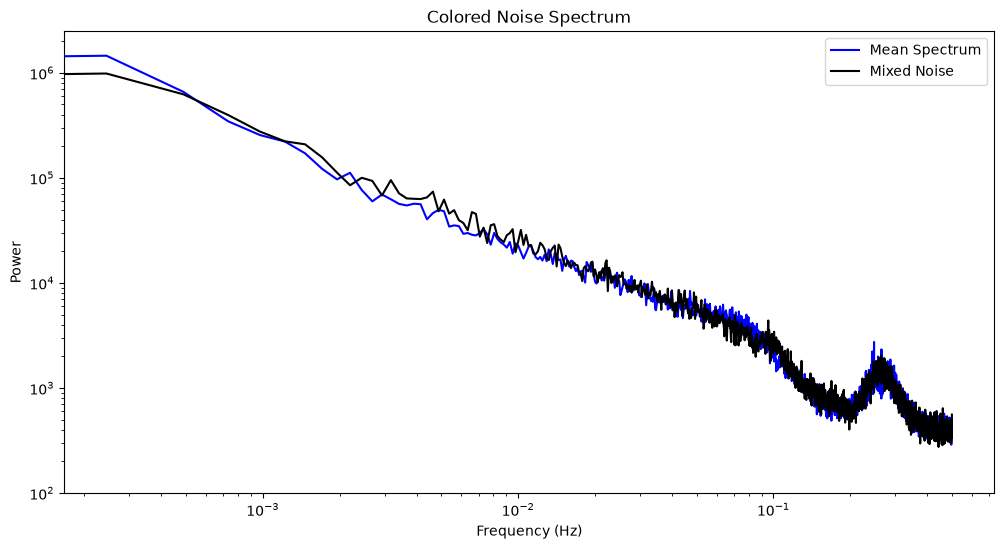

In [56]:
random_state = np.random.RandomState(2)

# --- FILTER USAGE ---
fs = 1
num_samples = int(1.5e+5)
white_noise = random_state.randn(num_samples)

# Design a filter for alpha = 1.5 (between pink and brown)
sos_pink = diseno_filtro_fraccionario(alpha=-slope_fcut0, fs=fs, num_etapas=8) # num_etapas=8
sos_brown = diseno_filtro_fraccionario(alpha=-slope_fcut1, fs=fs, num_etapas=6) # num_etapas=6

# Apply the IIR cascade quickly with SciPy
pink_noise = sosfilt(sos_pink, white_noise)
brown_noise = sosfilt(sos_brown, white_noise)

pink_psd = psd(pink_noise, window_size=4096)
brown_psd = psd(brown_noise, window_size=4096)

filter_type = 'butter'
minimum_attenuation = None  # dB
p_order = 5
ripple = None
Q = 3
b, a = iirfilter(p_order, fcut0, rp=ripple, rs=minimum_attenuation, btype='lowpass', analog=False, ftype=filter_type, output='ba', fs=1)
c, d = iirfilter(p_order, [fcut0, fcut1], rp=ripple, rs=minimum_attenuation, btype='bandpass', analog=False, ftype=filter_type, output='ba', fs=1)
e, f = iirfilter(p_order, fcut1, rp=ripple, rs=minimum_attenuation, btype='highpass', analog=False, ftype=filter_type, output='ba', fs=1)
g, h = iirpeak(fcut0-0.01, 7, fs=1) # raising attenuation at the end of pink noise band
m, n = iirpeak(fcut1+0.0025, 5, fs=1) # raising attenuation at the beginning of white noise band

k, j = iirpeak(breathe_peak, Q, fs)


pink_noise_filtered = filtfilt(b, a, pink_noise)
brown_noise_filtered = filtfilt(17.5*c, d, brown_noise)
white_noise_filtered = filtfilt(0.017*e, f, white_noise)
peak_white_noise_filtered = filtfilt(0.016*k, j, white_noise)

mixed_noise_filtered = pink_noise_filtered + brown_noise_filtered + white_noise_filtered + peak_white_noise_filtered

peak_pink_noise_filtered = filtfilt(0.45*g, h, mixed_noise_filtered)
peak_brown_noise_filtered = filtfilt(0.5*m, n, mixed_noise_filtered)

mixed_noise_filtered =  peak_pink_noise_filtered + peak_brown_noise_filtered + mixed_noise_filtered

mixed_psd_filtered = psd(mixed_noise_filtered, window_size=4096)

plt.figure(figsize=(12, 6))
plt.loglog(freqs, mean_spectrum, label='Mean Spectrum', color='blue')
plt.loglog(freqs, mixed_psd_filtered, label='Mixed Noise', color='black')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.ylim(1e2, 0.25e7)
plt.title('Colored Noise Spectrum')
plt.legend()
plt.show()

In [73]:
import numpy as np
from scipy.signal import group_delay


class CausalIIR:
    """
    One IIR/FIR stage realized as a Direct Form II Transposed difference
    equation, updated ONE SAMPLE AT A TIME:

        y[n] = b[0]*x[n] + b[1]*x[n-1] + ... + b[M]*x[n-M]
                          - a[1]*y[n-1] - ... - a[N]*y[n-N]      (a[0]==1)

    b, a can be any length -- the same class handles a 1-tap filter or a
    30-tap filter without modification.
    """

    def __init__(self, b, a):
        b = np.atleast_1d(np.asarray(b, dtype=float))
        a = np.atleast_1d(np.asarray(a, dtype=float))
        if a[0] != 1.0:
            b = b / a[0]
            a = a / a[0]
        order = max(len(a), len(b)) - 1
        self.b = np.zeros(order + 1)
        self.a = np.zeros(order + 1)
        self.b[:len(b)] = b
        self.a[:len(a)] = a
        self.order = order
        self.z = np.zeros(order)

    def reset(self, zi=None):
        self.z[:] = 0.0 if zi is None else zi

    def process_sample(self, x):
        b, a, z = self.b, self.a, self.z
        y = b[0] * x + (z[0] if self.order else 0.0)
        for i in range(self.order - 1):
            z[i] = b[i + 1] * x - a[i + 1] * y + z[i + 1]
        if self.order:
            z[-1] = b[-1] * x - a[-1] * y
        return y

    def process_block(self, x_block):
        out = np.empty(len(x_block))
        for i, x in enumerate(x_block):
            out[i] = self.process_sample(x)
        return out

    def forecast(self, steps, x_future=0.0):
        """Zero-input (autonomous) roll-out of the SAME difference equation,
        `steps` samples ahead, assuming no new information in the raw input
        (x_future, default 0). Does not touch the real running state -- it
        works on a throwaway copy, so the real filter is unaffected and can
        keep processing real incoming samples afterwards. Because the filter
        is stable (poles inside the unit circle), this can only decay/ring
        down -- it cannot diverge."""
        b, a = self.b, self.a
        z = self.z.copy()
        out = np.empty(steps)
        for t in range(steps):
            y = b[0] * x_future + (z[0] if self.order else 0.0)
            if self.order:
                z_new = np.empty(self.order)
                for i in range(self.order - 1):
                    z_new[i] = b[i + 1] * x_future - a[i + 1] * y + z[i + 1]
                z_new[-1] = b[-1] * x_future - a[-1] * y
                z = z_new
            out[t] = y
        return out


class DelayLine:
    """A pure N-sample integer delay, used to time-align parallel branches
    that have different group delay before they are summed."""

    def __init__(self, n_samples):
        self.buf = np.zeros(max(int(round(n_samples)), 0))
        self.i = 0

    def process_sample(self, x):
        if len(self.buf) == 0:
            return x
        out = self.buf[self.i]
        self.buf[self.i] = x
        self.i = (self.i + 1) % len(self.buf)
        return out

    def forecast(self, steps, future_pushes=None):
        """Next `steps` outputs. As long as steps <= the delay length, these
        are ALREADY DETERMINED (sitting in the buffer already) -- a pure
        delay just replays the past, there is nothing to guess. Only once
        `steps` exceeds the buffer length do we need the values that would
        be pushed in from that point on (`future_pushes`, supplied by the
        caller as the upstream filter's own forecast)."""
        L = len(self.buf)
        out = np.empty(steps)
        for t in range(steps):
            out[t] = self.buf[(self.i + t) % L] if (L and t < L) else future_pushes[t - L]
        return out


def _gd_samples(b, a, f0, fs):
    """Group delay of (b, a), in samples, at frequency f0 (same units as fs)."""
    _, gd = group_delay((b, a), w=[f0], fs=fs)
    return float(gd[0])


class RRFilterBank:
    """
    Causal, sample-by-sample reimplementation of the filter graph you
    validated offline with `filtfilt`:

        x[n] -> LP(b,a)            \\
        x[n] -> BP(17.5*c,d)        + -> mixed[n] -> Peak(0.45*g,h)  \\
        x[n] -> HP(0.017*e,f)      /                -> Peak(0.5*m,n) + -> y[n]
        x[n] -> Peak(0.016*k,j)  --/                 mixed[n] -------/

    Only the (b,a)...(k,j) shaping-filter coefficients are used here -- the
    fractional pink/brown noise generator (sos_pink, sos_brown, sosfilt) and
    filtfilt were only for your offline PSD check and are intentionally not
    part of this online version.

    Every stage is a genuine difference equation with its own persistent
    state (CausalIIR), so `step()` can be called once per incoming RR
    interval, in order, with no batching and no look-ahead.

    Phase-delay handling
    --------------------
    `filtfilt` gave every stage zero phase, so summing the four first-stage
    branches (and later the two peak branches with `mixed`) was automatically
    time-aligned. A single causal pass is NOT zero phase, and the four
    branches have four *different* group delays (a lowpass, a bandpass, a
    highpass and a peak filter all delay their passband differently). Left
    uncorrected, this would smear/partially cancel features when the
    branches are added -- something that could not happen in your offline
    version. To fix this, the group delay of each branch is measured once
    (at its own characteristic frequency) and the faster branches are pushed
    through a plain integer `DelayLine` so every branch reaches the adder at
    the same time. The same is done for `mixed` vs. the two peak filters
    before the final sum.

    This aligns the branches with each other, but it cannot make the whole
    cascade zero phase -- a causal filter cannot see the future. `y[n]`
    returned by `step()` is therefore a clean, internally-consistent, but
    delayed estimate: it corresponds to what `filtfilt` would have centered
    on sample `n - total_delay_samples`. That delay is reported in
    `total_delay_samples` / `total_delay_seconds`.

    `forecast(steps)` turns that lagging estimate into an explicit look-
    ahead: a zero-input (autonomous) roll-out of the same cascade for
    `steps` samples (1 to 30, your choice, default `max_forecast_steps`),
    i.e. "what y[n+1..n+steps] will do if no new RR interval arrives" --
    see its docstring for why this, rather than extrapolating a trend line,
    is the sound way to look forward through a resonant filter.
    """

    def __init__(self, b, a, c, d, e, f, g, h, m, n, k, j,
                 fcut0, fcut1, breathe_peak, fs=1.0, max_forecast_steps=10):
        if not (1 <= max_forecast_steps <= 30):
            raise ValueError("max_forecast_steps must be between 1 and 30")
        self.fs = fs
        self.max_forecast_steps = max_forecast_steps

        # ---------------- stage 1: four parallel branches, all fed x[n] --
        self.lp = CausalIIR(b, a)
        self.bp = CausalIIR(17.5 * c, d)
        self.hp = CausalIIR(0.017 * e, f)
        self.pk_breathe = CausalIIR(0.016 * k, j)

        branch_delay = {
            "lp": _gd_samples(b, a, fcut0, fs),
            "bp": _gd_samples(c, d, 0.5 * (fcut0 + fcut1), fs),
            "hp": _gd_samples(e, f, fcut1, fs),
            "pk_breathe": _gd_samples(k, j, breathe_peak, fs),
        }
        max_stage1 = max(branch_delay.values())
        self.align_lp = DelayLine(max_stage1 - branch_delay["lp"])
        self.align_bp = DelayLine(max_stage1 - branch_delay["bp"])
        self.align_hp = DelayLine(max_stage1 - branch_delay["hp"])
        self.align_pk_breathe = DelayLine(max_stage1 - branch_delay["pk_breathe"])
        self.stage1_delay = max_stage1

        # ---------------- stage 2: two peak filters fed with mixed[n] ----
        self.pk_pink = CausalIIR(0.45 * g, h)
        self.pk_brown = CausalIIR(0.5 * m, n)

        stage2_delay = {
            "pk_pink": _gd_samples(g, h, fcut0 - 0.01, fs),
            "pk_brown": _gd_samples(m, n, fcut1 + 0.0025, fs),
        }
        max_stage2 = max(stage2_delay.values())
        self.align_mixed = DelayLine(max_stage2)  # mixed[] itself has 0 delay
        self.align_pk_pink = DelayLine(max_stage2 - stage2_delay["pk_pink"])
        self.align_pk_brown = DelayLine(max_stage2 - stage2_delay["pk_brown"])
        self.stage2_delay = max_stage2

        self.total_delay_samples = self.stage1_delay + self.stage2_delay

    @property
    def total_delay_seconds(self):
        return self.total_delay_samples / self.fs

    def step(self, x):
        """Feed ONE new RR interval, return the current filtered value y[n]
        (a delayed, branch-aligned equivalent of the offline filtfilt output)."""
        lp = self.align_lp.process_sample(self.lp.process_sample(x))
        bp = self.align_bp.process_sample(self.bp.process_sample(x))
        hp = self.align_hp.process_sample(self.hp.process_sample(x))
        pkb = self.align_pk_breathe.process_sample(self.pk_breathe.process_sample(x))
        mixed = lp + bp + hp + pkb

        pk_pink = self.align_pk_pink.process_sample(self.pk_pink.process_sample(mixed))
        pk_brown = self.align_pk_brown.process_sample(self.pk_brown.process_sample(mixed))
        mixed_aligned = self.align_mixed.process_sample(mixed)

        return pk_pink + pk_brown + mixed_aligned

    def forecast(self, steps=None):
        """
        Zero-input roll-out of the WHOLE cascade `steps` samples into the
        future (default: `max_forecast_steps`, capped 1-30), assuming no new
        information arrives on the raw RR input (x_future = 0 for the four
        first-stage branches). Returns an array `y_forecast[0..steps-1]`,
        the natural continuation of y[n] under "nothing new happens".

        This replaces a naive linear/polynomial extrapolation of y[n]:
        tested on this cascade, that alternative diverges badly whenever a
        narrow, low-frequency iirpeak branch (large group delay, see
        `total_delay_samples`) dominates. Rolling the actual pole
        recursion forward instead can only ring down toward zero (the
        filters are stable), so it is bounded by construction and it
        literally reuses "the coefficients obtained previously" rather
        than fitting an unrelated trend line.

        IMPORTANT: x_future = 0 assumes the signal fed into `step()` is
        already zero-mean/detrended (e.g. RR intervals with the mean or a
        slow trend removed). If you feed raw RR values (~800 ms, not
        zero-mean) straight in, the lowpass branch in particular will carry
        that offset through almost unattenuated, and this roll-out will
        just hold near that offset rather than "ring down" -- detrend
        first if that's not what you want.
        """
        if steps is None:
            steps = self.max_forecast_steps
        if not (1 <= steps <= 30):
            raise ValueError("steps must be between 1 and 30")

        lp_free = self.lp.forecast(steps, 0.0)
        bp_free = self.bp.forecast(steps, 0.0)
        hp_free = self.hp.forecast(steps, 0.0)
        pkb_free = self.pk_breathe.forecast(steps, 0.0)

        lp_out = self.align_lp.forecast(steps, lp_free)
        bp_out = self.align_bp.forecast(steps, bp_free)
        hp_out = self.align_hp.forecast(steps, hp_free)
        pkb_out = self.align_pk_breathe.forecast(steps, pkb_free)
        mixed = lp_out + bp_out + hp_out + pkb_out

        # stage 2 filters need mixed[n+1..] as *their* future input, which we
        # only just computed above -- feed it through a scratch copy of each
        # peak filter's state so the real state (used by the next real
        # step()) is left untouched.
        pk_pink_free = np.empty(steps)
        z = self.pk_pink.z.copy()
        b, a, order = self.pk_pink.b, self.pk_pink.a, self.pk_pink.order
        for t in range(steps):
            y = b[0] * mixed[t] + (z[0] if order else 0.0)
            if order:
                zn = np.empty(order)
                for i in range(order - 1):
                    zn[i] = b[i + 1] * mixed[t] - a[i + 1] * y + z[i + 1]
                zn[-1] = b[-1] * mixed[t] - a[-1] * y
                z = zn
            pk_pink_free[t] = y

        pk_brown_free = np.empty(steps)
        z = self.pk_brown.z.copy()
        b, a, order = self.pk_brown.b, self.pk_brown.a, self.pk_brown.order
        for t in range(steps):
            y = b[0] * mixed[t] + (z[0] if order else 0.0)
            if order:
                zn = np.empty(order)
                for i in range(order - 1):
                    zn[i] = b[i + 1] * mixed[t] - a[i + 1] * y + z[i + 1]
                zn[-1] = b[-1] * mixed[t] - a[-1] * y
                z = zn
            pk_brown_free[t] = y

        pk_pink_out = self.align_pk_pink.forecast(steps, pk_pink_free)
        pk_brown_out = self.align_pk_brown.forecast(steps, pk_brown_free)
        mixed_out = self.align_mixed.forecast(steps, mixed)

        return pk_pink_out + pk_brown_out + mixed_out


if __name__ == "__main__":
    # ------------------------------------------------------------------
    # Usage example, built from your exact filter-design lines.
    # Plug in your real fcut0, fcut1, breathe_peak, p_order, Q, filter_type.
    # ------------------------------------------------------------------

    bank = RRFilterBank(b, a, c, d, e, f, g, h, m, n, k, j,
                         fcut0, fcut1, breathe_peak, fs=fs,
                         max_forecast_steps=20)

    print(f"stage-1 (branch-alignment) delay : {bank.stage1_delay:.2f} samples")
    print(f"stage-2 (peak-alignment) delay    : {bank.stage2_delay:.2f} samples")
    print(f"total input->output delay         : {bank.total_delay_samples:.2f} samples "
          f"({bank.total_delay_seconds:.2f} s at fs={fs})")

    # feed RR intervals one at a time, exactly as they arrive
    subject_test = subjects[0]
    subject_age = get_age_years(subject_test, ages_table)
    rr_mean_ref, rr_std_ref = get_rr_reference(subject_age)
    rr_buffer = np.loadtxt(pathlib.Path(series_path) / f"{subject_test}.txt", dtype=float)[:20]
    print(rr_buffer)
    mean_buffer = np.mean(rr_buffer)
    std_buffer = np.std(rr_buffer)
    rr_buffer = (rr_buffer - mean_buffer) / std_buffer  # Normalize to z-scores
    # rr_buffer = (rr_buffer - rr_mean_ref) / rr_std_ref  # Normalize to z-scores
    for rr in rr_buffer:
        y = bank.step(rr)                 # current filtered/shaped value
        y_forecast = bank.forecast(5)     # next 5 samples if nothing new happens
        print(f"x={rr:+.3f}  ->  y={y:+.5f}   forecast(1..5)={np.round(y_forecast, 4)}")
        next_rr_pred = y_forecast * std_buffer + mean_buffer  # Convert back to original scale if needed
        print(f"Predicted next RR interval (original scale): {next_rr_pred} ms")


stage-1 (branch-alignment) delay : 9.39 samples
stage-2 (peak-alignment) delay    : 28.25 samples
total input->output delay         : 37.64 samples (37.64 s at fs=1)
[656. 649. 648. 656. 657. 640. 672. 664. 664. 672. 664. 680. 695. 696.
 687. 641. 687. 672. 664. 672.]
x=-0.672  ->  y=-0.00001   forecast(1..5)=[-0.0004 -0.0028 -0.0074 -0.0068  0.0097]
Predicted next RR interval (original scale): [666.79286445 666.75424611 666.68110391 666.69086772 666.95513176] ms
x=-1.108  ->  y=-0.00046   forecast(1..5)=[-0.0036 -0.0121 -0.019  -0.0015  0.0495]
Predicted next RR interval (original scale): [666.74248567 666.60569473 666.49490935 666.7752656  667.59533256] ms
x=-1.170  ->  y=-0.00359   forecast(1..5)=[-0.0129 -0.0239 -0.0144  0.0377  0.1025]
Predicted next RR interval (original scale): [666.59327358 666.4152637  666.56829833 667.40536156 668.44657532] ms
x=-0.672  ->  y=-0.01288   forecast(1..5)=[-0.0244 -0.0173  0.0303  0.0957  0.0947]
Predicted next RR interval (original scale): [666.

In [60]:
y_forecast

array([-0.00031409])

In [52]:
# Bundle all filter pairs
filter_bank = [(b, a), (c, d), (e, f), (g, h), (k, j)]
subject_test = subjects[0]
subject_age = get_age_years(subject_test, ages_table)
rr_mean_ref, rr_std_ref = get_rr_reference(subject_age)
n = 60
rr_buffer = np.loadtxt(pathlib.Path(series_path) / f"{subject_test}.txt", dtype=float)[n:n+30]
print(rr_buffer)
mean_buffer = np.mean(rr_buffer)
std_buffer = np.std(rr_buffer)
# rr_buffer = (rr_buffer - mean_buffer) / std_buffer  # Normalize to z-scores
rr_buffer = (rr_buffer - rr_mean_ref) / rr_std_ref  # Normalize to z-scores


next_rr_pred, full_series = predict_next_rr(rr_buffer, filter_bank)
next_rr_pred = next_rr_pred * std_buffer + mean_buffer  # Convert back to original scale
print(f"Predicted RR: {next_rr_pred:.2f} ms")

[727. 789. 781. 750. 766. 773. 742. 766. 805. 773. 742. 781. 758. 781.
 790. 773. 727. 734. 711. 711. 726. 743. 710. 727. 781. 758. 727. 851.
 836. 813.]
Predicted RR: 774.53 ms


In [75]:
full_series

array([ 152.72318514,   23.65456988,  132.03422489, -113.16334039,
         34.14936579,  180.97803107,  140.81622781,  153.65565435,
        276.9975965 ,  453.19600283])

In [78]:
a

array([  1.        ,  -5.14278353,  11.92876865, -16.2038477 ,
        14.0451779 ,  -7.93264852,   2.84490965,  -0.59132475,
         0.05446375])